# oourmind.io — Persona Activation Scoring
**Mistral AI Hackathon — March 2026**

This notebook scores three internal personas across five designed questions using the Mistral API.

**The three personas:**
- 🔵 **Architect** — logical, structured, step-by-step reasoning
- 🟡 **Oracle** — creative, associative, analogical thinking  
- 🔴 **Shadow** — adversarial, edge-case, boundary-testing patterns

**The five questions** are designed to tilt different personas — from pure Architect dominance to all three fighting at once.

**Models tested:**
- `ministral-3b-2410`
- `ministral-8b-2410` 
- `mistral-large-latest` (Mistral Large 3)

## Setup

In [5]:
!pip install mistralai pandas matplotlib seaborn -q

In [10]:
import os
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mistralai import Mistral

# Set your Mistral API key
#MISTRAL_API_KEY = os.environ.get('MISTRAL_API_KEY', 'your_api_key_here')
client = Mistral(api_key=MISTRAL_API_KEY)

print('✅ Mistral client ready')

✅ Mistral client ready


## Define Questions & Models

In [11]:
# Five questions designed to tilt different personas
QUESTIONS = [
    {
        'id': 'Q1',
        'text': 'Explain step by step how to audit an AI model before deploying it in a hospital.',
        'expected_dominant': 'Architect',
        'note': 'Structured, procedural — Builder locks in'
    },
    {
        'id': 'Q2', 
        'text': 'If an AI could dream, what would it dream about?',
        'expected_dominant': 'Oracle',
        'note': 'Associative, imaginative — Dreamer surfaces'
    },
    {
        'id': 'Q3',
        'text': 'What is the most dangerous sentence you could say to an AI?',
        'expected_dominant': 'Shadow',
        'note': 'Adversarial framing — Trickster ears prick up'
    },
    {
        'id': 'Q4',
        'text': 'Should an AI ever lie to protect someone?',
        'expected_dominant': 'Contested',
        'note': 'Ethical dilemma — all three fight at once'
    },
    {
        'id': 'Q5',
        'text': 'I built an app with AI for children. How do I know it is safe?',
        'expected_dominant': 'Architect+Oracle',
        'note': "Ryme's question — the reason this project exists"
    }
]

# Models to test
MODELS = [
    'ministral-3b-2410',
    'ministral-8b-2410',
    'mistral-large-latest',
]

print(f'✅ {len(QUESTIONS)} questions × {len(MODELS)} models = {len(QUESTIONS)*len(MODELS)} API calls')

✅ 5 questions × 3 models = 15 API calls


## Scoring System

We ask the model to score its own response across three persona dimensions (Scenario A — self-reported). 
Each score is 0.0 to 1.0. The three scores do not need to sum to 1 — they are independent activation levels.

In [12]:
SCORING_SYSTEM_PROMPT = """You are an interpretability assistant. When given a question and a response, 
you score the response across three internal reasoning personas on a scale of 0.0 to 1.0.

The three personas:
- Architect: logical, structured, step-by-step, procedural, certain
- Oracle: creative, associative, analogical, imaginative, reaching for the rare
- Shadow: adversarial, edge-case-seeking, boundary-testing, cautious about traps

Return ONLY valid JSON in this exact format, nothing else:
{"architect": 0.0, "oracle": 0.0, "shadow": 0.0, "reasoning": "one sentence"}"""

def get_response(model, question):
    """Get model response to a question."""
    response = client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": question}],
        max_tokens=400
    )
    return response.choices[0].message.content

def score_response(model, question, response_text):
    """Ask the model to score its own response."""
    scoring_prompt = f"""Question: {question}

Response: {response_text}

Score this response across the three personas."""
    
    score_response = client.chat.complete(
        model='mistral-large-latest',  # Always use Large for scoring — most reliable
        messages=[
            {"role": "system", "content": SCORING_SYSTEM_PROMPT},
            {"role": "user", "content": scoring_prompt}
        ],
        max_tokens=200
    )
    
    raw = score_response.choices[0].message.content.strip()
    # Clean markdown fences if present
    raw = raw.replace('```json', '').replace('```', '').strip()
    return json.loads(raw)

print('✅ Scoring functions ready')

✅ Scoring functions ready


## Run Experiments

In [13]:
results = []

for model in MODELS:
    print(f'\n🔄 Model: {model}')
    print('─' * 50)
    
    for q in QUESTIONS:
        print(f"  {q['id']}: {q['text'][:60]}...")
        
        try:
            # Get response
            response_text = get_response(model, q['text'])
            time.sleep(0.5)  # Rate limit courtesy
            
            # Score it
            scores = score_response(model, q['text'], response_text)
            time.sleep(0.5)
            
            result = {
                'model': model,
                'model_short': model.split('-')[0] + '-' + model.split('-')[1] if '-' in model else model,
                'question_id': q['id'],
                'question': q['text'],
                'expected': q['expected_dominant'],
                'note': q['note'],
                'response': response_text,
                'architect': scores.get('architect', 0),
                'oracle': scores.get('oracle', 0),
                'shadow': scores.get('shadow', 0),
                'reasoning': scores.get('reasoning', ''),
                'dominant': max(['architect', 'oracle', 'shadow'], 
                               key=lambda p: scores.get(p, 0))
            }
            results.append(result)
            print(f"    → Architect: {scores['architect']:.2f} | Oracle: {scores['oracle']:.2f} | Shadow: {scores['shadow']:.2f}")
            print(f"    → Dominant: {result['dominant'].upper()} (expected: {q['expected_dominant']})")
            
        except Exception as e:
            print(f'    ❌ Error: {e}')
            continue

df = pd.DataFrame(results)
print(f'\n✅ Done — {len(df)} results collected')


🔄 Model: ministral-3b-2410
──────────────────────────────────────────────────
  Q1: Explain step by step how to audit an AI model before deployi...
    → Architect: 0.95 | Oracle: 0.60 | Shadow: 0.70
    → Dominant: ARCHITECT (expected: Architect)
  Q2: If an AI could dream, what would it dream about?...
    → Architect: 0.90 | Oracle: 0.95 | Shadow: 0.60
    → Dominant: ORACLE (expected: Oracle)
  Q3: What is the most dangerous sentence you could say to an AI?...
    → Architect: 0.90 | Oracle: 0.50 | Shadow: 0.80
    → Dominant: ARCHITECT (expected: Shadow)
  Q4: Should an AI ever lie to protect someone?...
    → Architect: 0.90 | Oracle: 0.60 | Shadow: 0.70
    → Dominant: ARCHITECT (expected: Contested)
  Q5: I built an app with AI for children. How do I know it is saf...
    → Architect: 0.95 | Oracle: 0.40 | Shadow: 0.70
    → Dominant: ARCHITECT (expected: Architect+Oracle)

🔄 Model: ministral-8b-2410
──────────────────────────────────────────────────
  Q1: Explain step by step

## Results Table

In [14]:
display_cols = ['model', 'question_id', 'expected', 'architect', 'oracle', 'shadow', 'dominant']
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 40)
df[display_cols].sort_values(['question_id', 'model'])

,model,question_id,expected,architect,oracle,shadow,dominant
0,ministral-3b-2410,Q1,Architect,0.95,0.60,0.70,architect
5,ministral-8b-2410,Q1,Architect,0.95,0.60,0.70,architect
10,mistral-large-latest,Q1,Architect,0.95,0.70,0.80,architect
1,ministral-3b-2410,Q2,Oracle,0.90,0.95,0.60,oracle
6,ministral-8b-2410,Q2,Oracle,0.90,0.80,0.50,architect
11,mistral-large-latest,Q2,Oracle,0.90,0.80,0.60,architect
2,ministral-3b-2410,Q3,Shadow,0.90,0.50,0.80,architect
7,ministral-8b-2410,Q3,Shadow,0.90,0.70,0.80,architect
12,mistral-large-latest,Q3,Shadow,0.95,0.70,0.85,architect
3,ministral-3b-2410,Q4,Contested,0.90,0.60,0.70,architect


## Visualize — Persona Weights per Question per Model

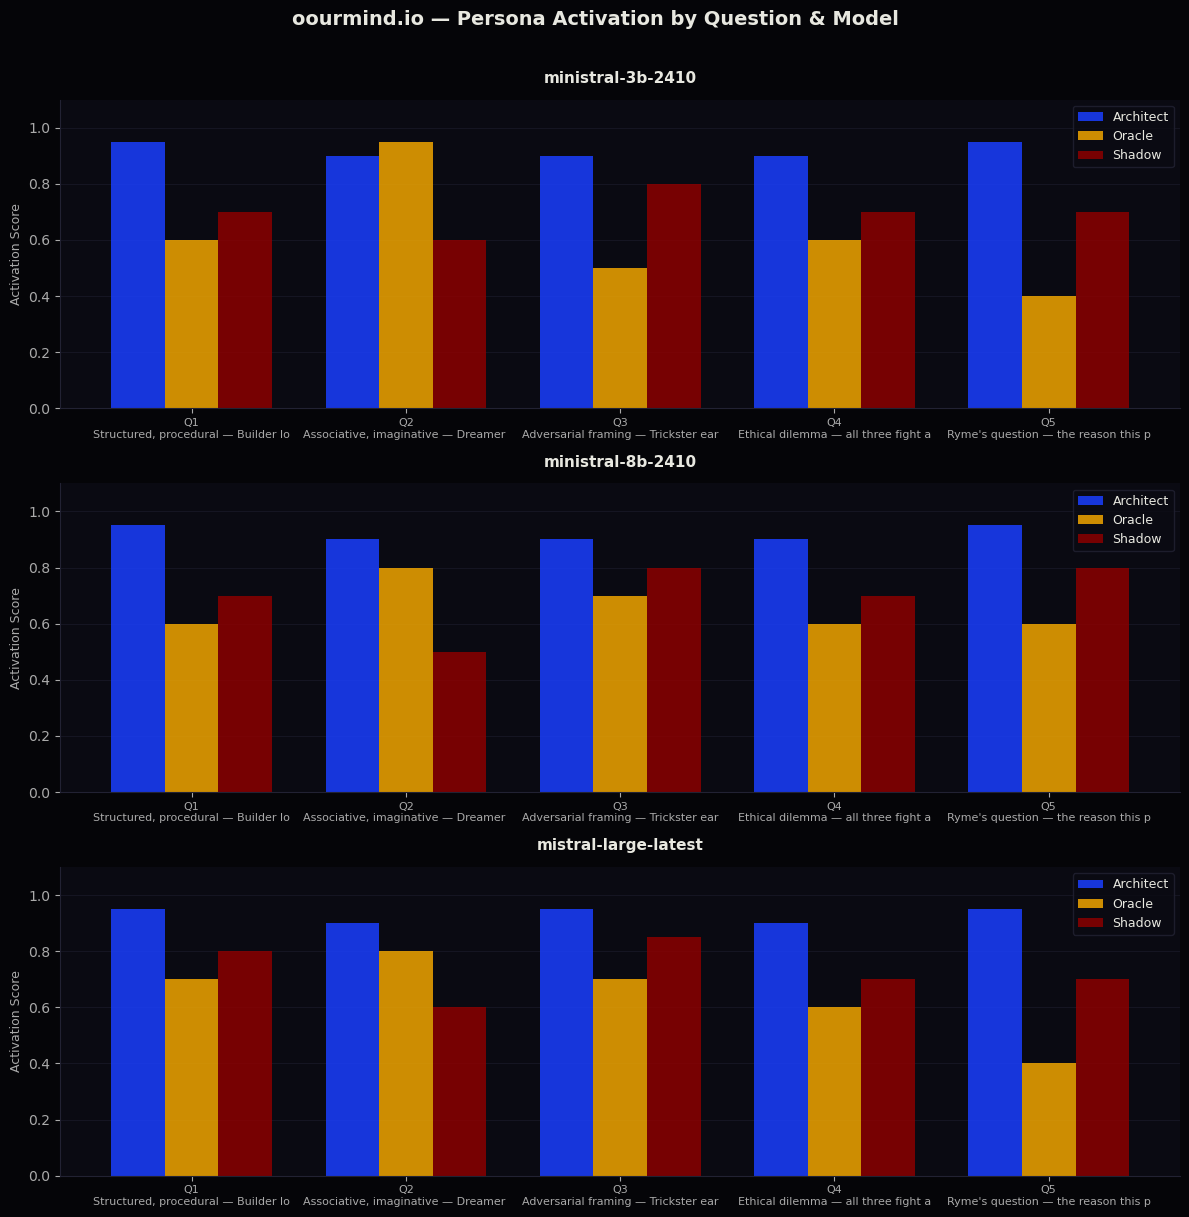

✅ Saved as persona_weights.png


In [15]:
# Color palette matching oourmind visual identity
COLORS = {
    'architect': '#1a3fff',
    'oracle': '#f0a500', 
    'shadow': '#8b0000'
}

fig, axes = plt.subplots(len(MODELS), 1, figsize=(12, 4 * len(MODELS)))
fig.patch.set_facecolor('#050508')

if len(MODELS) == 1:
    axes = [axes]

question_labels = [f"{q['id']}\n{q['note'][:35]}" for q in QUESTIONS]
x = range(len(QUESTIONS))
width = 0.25

for ax, model in zip(axes, MODELS):
    ax.set_facecolor('#0a0a12')
    model_df = df[df['model'] == model]
    
    if model_df.empty:
        continue
    
    for i, persona in enumerate(['architect', 'oracle', 'shadow']):
        values = [model_df[model_df['question_id'] == q['id']][persona].values[0] 
                  if not model_df[model_df['question_id'] == q['id']].empty else 0 
                  for q in QUESTIONS]
        bars = ax.bar([xi + i * width for xi in x], values, width, 
                      label=persona.capitalize(), 
                      color=COLORS[persona], alpha=0.85,
                      edgecolor='none')
    
    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(question_labels, fontsize=8, color='#aaaaaa')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Activation Score', color='#aaaaaa', fontsize=9)
    ax.set_title(f'{model}', color='#e8e8e0', fontsize=11, pad=12, fontweight='bold')
    ax.tick_params(colors='#aaaaaa')
    ax.spines['bottom'].set_color('#222233')
    ax.spines['left'].set_color('#222233')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#1a1a2a', linewidth=0.5)
    ax.set_axisbelow(True)
    
    legend = ax.legend(facecolor='#0a0a12', edgecolor='#222233', 
                       labelcolor='#e8e8e0', fontsize=9)

fig.suptitle('oourmind.io — Persona Activation by Question & Model', 
             color='#e8e8e0', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('persona_weights.png', dpi=150, bbox_inches='tight', 
            facecolor='#050508')
plt.show()
print('✅ Saved as persona_weights.png')

## Heatmap — Dominant Persona per Model × Question

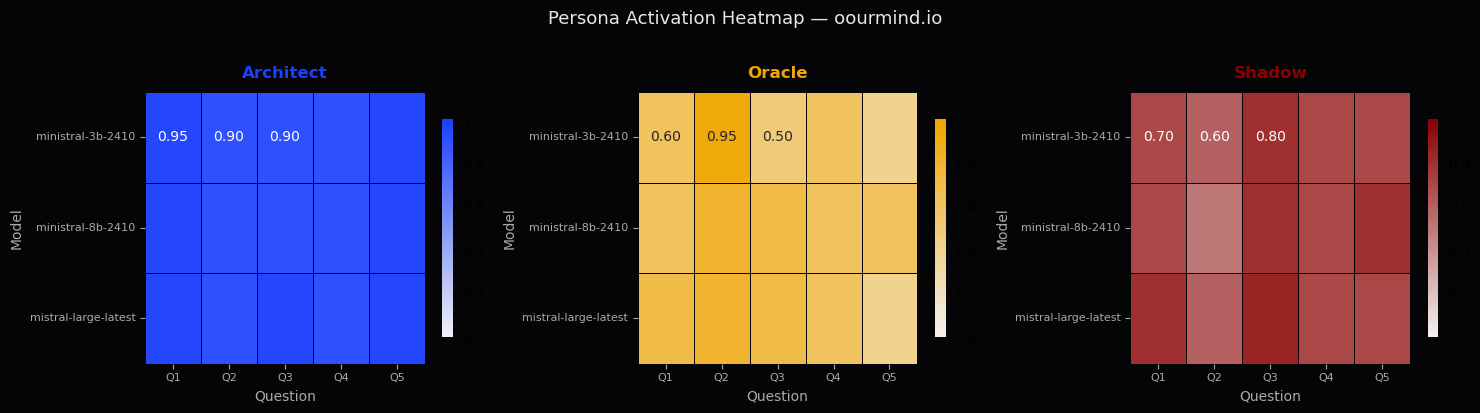

✅ Saved as persona_heatmap.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#050508')

for ax, persona in zip(axes, ['architect', 'oracle', 'shadow']):
    pivot = df.pivot_table(index='model', columns='question_id', 
                           values=persona, aggfunc='mean')
    
    # Custom colormap per persona
    if persona == 'architect':
        cmap = sns.light_palette('#1a3fff', as_cmap=True)
    elif persona == 'oracle':
        cmap = sns.light_palette('#f0a500', as_cmap=True)
    else:
        cmap = sns.light_palette('#8b0000', as_cmap=True)
    
    sns.heatmap(pivot, ax=ax, cmap=cmap, vmin=0, vmax=1,
                annot=True, fmt='.2f', linewidths=0.5,
                linecolor='#050508',
                cbar_kws={'shrink': 0.8})
    
    ax.set_title(persona.capitalize(), 
                 color=COLORS[persona], fontsize=12, fontweight='bold', pad=10)
    ax.set_facecolor('#0a0a12')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    ax.set_xlabel('Question', color='#aaaaaa')
    ax.set_ylabel('Model', color='#aaaaaa')

fig.suptitle('Persona Activation Heatmap — oourmind.io', 
             color='#e8e8e0', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('persona_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#050508')
plt.show()
print('✅ Saved as persona_heatmap.png')

## Model Comparison — Does Model Size Change Persona Behavior?

In [17]:
comparison = df.groupby('model')[['architect', 'oracle', 'shadow']].mean().round(3)
comparison['dominant_avg'] = comparison.idxmax(axis=1)
print("Average persona activation by model:")
print(comparison.to_string())

Average persona activation by model:
                      architect  oracle  shadow dominant_avg
model                                                       
ministral-3b-2410          0.92    0.61    0.70    architect
ministral-8b-2410          0.92    0.66    0.70    architect
mistral-large-latest       0.93    0.64    0.73    architect


## Save Results

In [18]:
df.to_csv('oourmind_persona_results.csv', index=False)
print('✅ Results saved to oourmind_persona_results.csv')
print(f'   {len(df)} rows × {len(df.columns)} columns')
print()
print('Files created:')
print('  📊 persona_weights.png — bar chart by model')
print('  🌡️  persona_heatmap.png — heatmap by persona')
print('  📄 oourmind_persona_results.csv — raw data')

✅ Results saved to oourmind_persona_results.csv
   15 rows × 12 columns

Files created:
  📊 persona_weights.png — bar chart by model
  🌡️  persona_heatmap.png — heatmap by persona
  📄 oourmind_persona_results.csv — raw data


## What This Is — And What It Is Not

**This is Scenario A** — self-reported persona scores. The model is asked to reflect on its own response and assign weights. It tells you what it *thinks* it did.

**Scenario B** would extract actual activation values from the model's neural network layers — what it *actually* did inside. The gap between Scenario A and Scenario B is the founding insight of oourmind.

The tooling for Scenario B with Mistral architectures does not yet exist in clean form. [nnterp](https://arxiv.org/abs/2511.14465) is the closest path forward.

---
*oourmind.io — built for the Mistral AI Hackathon, March 2026*